# Лабораторная работа
## Тема: DBSCAN

### 1. Название и краткая информация о сдаваемом методе

`DBSCAN` (`Density-Based Spatial Clustering of Applications with Noise`) — алгоритм кластеризации, который объединяет объекты в кластеры по плотности их расположения в пространстве признаков. В отличие от `K-Means`, он не требует заранее задавать число кластеров и умеет выделять шумовые объекты. В данной лабораторной работе метод применяется к датасету рукописных цифр `Pendigits` из UCI, чтобы найти естественные группы похожих траекторий пера.
        


### 2. Блок с используемыми библиотеками

В работе используются `pandas` и `numpy` для подготовки данных, `matplotlib` и `seaborn` для визуализации, а также инструменты `scikit-learn` для стандартизации, снижения размерности методом `PCA`, подбора параметров и обучения модели `DBSCAN`.
        


In [16]:
import os
import warnings
from pathlib import Path

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
        


### 3. Блок с описанием и демонстрацией используемого датасета

Для лабораторной работы используется датасет **Pen-Based Recognition of Handwritten Digits (Pendigits)** из [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits). После объединения обучающей и тестовой частей он содержит **10 992** объекта. Каждый объект представляет собой рукописную цифру, записанную как последовательность координат точек движения пера: всего используются **16 числовых признаков**, то есть восемь пар координат `(x, y)`.

По смыслу таблица состоит из траекторий написания цифр от `0` до `9`. В исходном наборе имеется столбец `digit`, который показывает реальную цифру, однако при обучении `DBSCAN` он не используется. Алгоритм получает только координаты и сам пытается выделить плотные области в пространстве признаков. Метка цифры сохраняется лишь для последующей интерпретации и дополнительной оценки качества кластеризации.
        


In [26]:
column_names = [
    "x1", "y1", "x2", "y2", "x3", "y3", "x4", "y4",
    "x5", "y5", "x6", "y6", "x7", "y7", "x8", "y8", "digit"
]

candidate_dirs = [
    Path("."),
    Path("/content"),
    Path("/mnt/data"),
]

for base_dir in candidate_dirs:
    train_path = base_dir / "pendigits.tra"
    test_path = base_dir / "pendigits.tes"
    if train_path.exists() and test_path.exists():
        break
else:
    raise FileNotFoundError("Файлы pendigits.tra и pendigits.tes не найдены рядом с ноутбуком.")

train_df = pd.read_csv(train_path, header=None, names=column_names)
test_df = pd.read_csv(test_path, header=None, names=column_names)
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Размер train-части: {train_df.shape}")
print(f"Размер test-части: {test_df.shape}")
print(f"Итоговый размер датасета: {df.shape}")
display(df.head(10))
        


Размер train-части: (7494, 17)
Размер test-части: (3498, 17)
Итоговый размер датасета: (10992, 17)


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,x6,y6,x7,y7,x8,y8,digit
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1
5,100,100,88,99,49,74,17,47,0,16,37,0,73,16,20,20,6
6,0,100,3,72,26,35,85,35,100,71,73,97,65,49,66,0,4
7,0,39,2,62,11,5,63,0,100,43,89,99,36,100,0,57,0
8,13,89,12,50,72,38,56,0,4,17,0,61,32,94,100,100,5
9,57,100,22,72,0,31,25,0,75,13,100,50,75,87,26,85,0


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x1      10992 non-null  int64
 1   y1      10992 non-null  int64
 2   x2      10992 non-null  int64
 3   y2      10992 non-null  int64
 4   x3      10992 non-null  int64
 5   y3      10992 non-null  int64
 6   x4      10992 non-null  int64
 7   y4      10992 non-null  int64
 8   x5      10992 non-null  int64
 9   y5      10992 non-null  int64
 10  x6      10992 non-null  int64
 11  y6      10992 non-null  int64
 12  x7      10992 non-null  int64
 13  y7      10992 non-null  int64
 14  x8      10992 non-null  int64
 15  y8      10992 non-null  int64
 16  digit   10992 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB

Статистическое описание признаков:


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,x6,y6,x7,y7,x8,y8,digit
count,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00
mean,38.81,85.12,40.61,83.77,49.77,65.57,51.22,44.50,56.87,33.70,60.52,34.83,55.02,34.94,47.29,28.85,4.43
std,34.26,16.22,26.34,19.16,34.10,27.00,30.58,29.91,34.14,27.25,37.29,27.12,22.34,33.16,41.76,35.78,2.88
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.00,76.00,20.00,72.00,18.00,49.00,28.00,23.00,29.00,7.00,23.00,11.00,42.00,5.00,0.00,0.00,2.00
50%,32.00,89.00,40.00,91.00,53.00,71.00,53.50,43.00,60.00,33.00,73.00,30.00,53.00,27.00,40.00,9.00,4.00
75%,65.00,100.00,58.00,100.00,78.00,86.00,74.00,64.00,89.00,54.00,97.00,55.00,68.00,47.00,100.00,51.00,7.00
max,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,9.00



Количество пропусков по столбцам:


,missing_values
x1,0
y1,0
x2,0
y2,0
x3,0
y3,0
x4,0
y4,0
x5,0
y5,0



Распределение цифр в исходных метках:


,count
digit,
0,1143
1,1143
2,1144
3,1055
4,1144
5,1055
6,1056
7,1142
8,1055


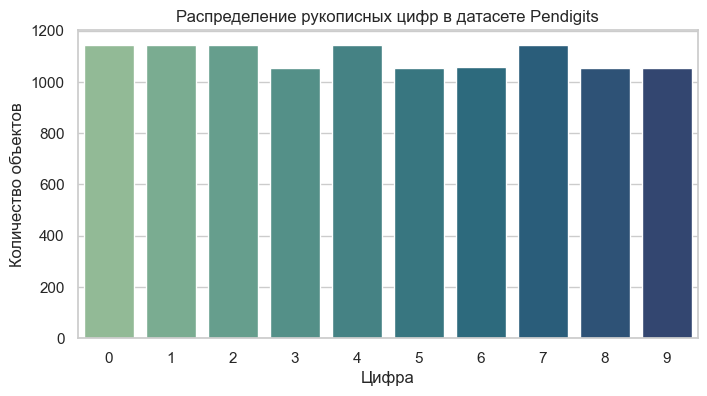

In [18]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание признаков:")
display(df.describe().round(2))

print("\nКоличество пропусков по столбцам:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nРаспределение цифр в исходных метках:")
digit_distribution = df["digit"].value_counts().sort_index().to_frame("count")
display(digit_distribution)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="digit", order=sorted(df["digit"].unique()), palette="crest")
plt.title("Распределение рукописных цифр в датасете Pendigits")
plt.xlabel("Цифра")
plt.ylabel("Количество объектов")
plt.show()
        


### 4. Блок с предварительной обработкой датасета

Перед обучением алгоритма из набора отделяются признаки и служебная метка `digit`. Далее выполняется стандартизация, поскольку `DBSCAN` использует расстояния между объектами и чувствителен к масштабу признаков. Для более устойчивой работы алгоритма в многомерном пространстве применяется `PCA`: шесть главных компонент используются для поиска плотностной структуры, а две главные компоненты — для визуализации результата.
        


In [19]:
X = df.drop(columns=["digit"])
y_reference = df["digit"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_dbscan = PCA(n_components=6, random_state=RANDOM_STATE)
X_dbscan = pca_dbscan.fit_transform(X_scaled)

pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
X_visual = pca_visual.fit_transform(X_scaled)

print(f"Матрица исходных признаков: {X.shape}")
print(f"Форма данных после PCA для DBSCAN: {X_dbscan.shape}")
print("Доля объясненной дисперсии 6 компонент:")
print(np.round(pca_dbscan.explained_variance_ratio_, 4))
        


Матрица исходных признаков: (10992, 16)
Форма данных после PCA для DBSCAN: (10992, 6)
Доля объясненной дисперсии 6 компонент:
[0.2948 0.2018 0.1611 0.0769 0.0664 0.0498]


### 6. Блок с обучением модели

Для `DBSCAN` особенно важны параметры `eps` и `min_samples`. Чтобы подобрать рабочее значение `eps`, сначала строится график расстояний до 15-го ближайшего соседа, а затем проводится серия запусков алгоритма при разных значениях `eps`. В качестве итоговой конфигурации выбирается вариант, который дает число кластеров, близкое к ожидаемым 10 цифрам, и при этом сохраняет разумный баланс между долей шума и качеством разделения объектов.
        


In [21]:
eps_values = [0.65, 0.75, 0.85, 0.95, 1.05, 1.15, 1.25]
eps_results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_dbscan)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = float((labels == -1).mean())
    ari = adjusted_rand_score(y_reference, labels)

    if n_clusters >= 2:
        mask = labels != -1
        if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
            silhouette = silhouette_score(X_dbscan[mask], labels[mask])
        else:
            silhouette = np.nan
    else:
        silhouette = np.nan

    eps_results.append(
        {
            "eps": eps,
            "clusters": n_clusters,
            "noise_ratio": round(noise_ratio, 4),
            "silhouette": round(float(silhouette), 4) if not np.isnan(silhouette) else np.nan,
            "ARI": round(float(ari), 4),
        }
    )

eps_results_df = pd.DataFrame(eps_results)
eps_results_df["cluster_gap"] = (eps_results_df["clusters"] - 10).abs()
display(eps_results_df.sort_values(["cluster_gap", "ARI", "noise_ratio"], ascending=[True, False, True]))
        


,eps,clusters,noise_ratio,silhouette,ARI,cluster_gap
2,0.85,11,0.1298,0.1030,0.3556,1
3,0.95,12,0.0751,-0.0541,0.1464,2
1,0.75,13,0.2109,0.1102,0.3971,3
4,1.05,7,0.0382,-0.2086,0.0024,3
0,0.65,16,0.3162,0.3569,0.4265,6
5,1.15,4,0.0209,-0.1750,0.0009,6
6,1.25,3,0.0105,-0.1706,0.0004,7


In [22]:
best_row = eps_results_df.sort_values(["cluster_gap", "ARI", "noise_ratio", "silhouette"], ascending=[True, False, True, False]).iloc[0]
eps_final = float(best_row["eps"])

dbscan_model = DBSCAN(eps=eps_final, min_samples=min_samples)
cluster_labels = dbscan_model.fit_predict(X_dbscan)

cluster_count = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_count = int((cluster_labels == -1).sum())
noise_ratio = noise_count / len(cluster_labels)
ari_final = adjusted_rand_score(y_reference, cluster_labels)

non_noise_mask = cluster_labels != -1
if cluster_count >= 2 and len(np.unique(cluster_labels[non_noise_mask])) > 1:
    silhouette_final = silhouette_score(X_dbscan[non_noise_mask], cluster_labels[non_noise_mask])
else:
    silhouette_final = np.nan

metrics_df = pd.DataFrame(
    {
        "Метрика": ["min_samples", "eps", "Количество кластеров", "Доля шума", "Silhouette", "Adjusted Rand Index"],
        "Значение": [
            min_samples,
            round(eps_final, 4),
            cluster_count,
            round(noise_ratio, 4),
            round(float(silhouette_final), 4) if not np.isnan(silhouette_final) else np.nan,
            round(float(ari_final), 4),
        ],
    }
)

print(f"Выбраны параметры: min_samples = {min_samples}, eps = {eps_final:.2f}")
display(metrics_df)
        


Выбраны параметры: min_samples = 15, eps = 0.85


,Метрика,Значение
0,min_samples,15.0000
1,eps,0.8500
2,Количество кластеров,11.0000
3,Доля шума,0.1298
4,Silhouette,0.1030
5,Adjusted Rand Index,0.3556


### 7. Блок с прогнозами модели

В задаче кластеризации под прогнозом понимается номер кластера, присвоенный каждому объекту. В `DBSCAN` часть наблюдений может быть отнесена к шуму и получает метку `-1`. Ниже показаны первые объекты датасета с найденными метками кластеров и реальными цифрами для интерпретации результата.
        


In [23]:
results_df = X.reset_index(drop=True).copy()
results_df["Истинная цифра"] = y_reference.reset_index(drop=True)
results_df["Метка кластера DBSCAN"] = cluster_labels

display(results_df.head(15))

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index().rename_axis("cluster").to_frame("count")
display(cluster_sizes.head(20))
        


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,x6,y6,x7,y7,x8,y8,Истинная цифра,Метка кластера DBSCAN
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8,7
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2,0
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4,2
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1,1
5,100,100,88,99,49,74,17,47,0,16,37,0,73,16,20,20,6,2
6,0,100,3,72,26,35,85,35,100,71,73,97,65,49,66,0,4,-1
7,0,39,2,62,11,5,63,0,100,43,89,99,36,100,0,57,0,2
8,13,89,12,50,72,38,56,0,4,17,0,61,32,94,100,100,5,3
9,57,100,22,72,0,31,25,0,75,13,100,50,75,87,26,85,0,2


,count
cluster,
-1,1427
0,2292
1,2907
2,3112
3,595
4,311
5,45
6,81
7,166


### 8. Блок с графиками выходных результатов

В итоговом блоке строятся основные графики для анализа работы `DBSCAN`: зависимость числа кластеров и доли шума от параметра `eps`, распределение размеров найденных кластеров и визуализация кластеров на плоскости первых двух главных компонент.
        


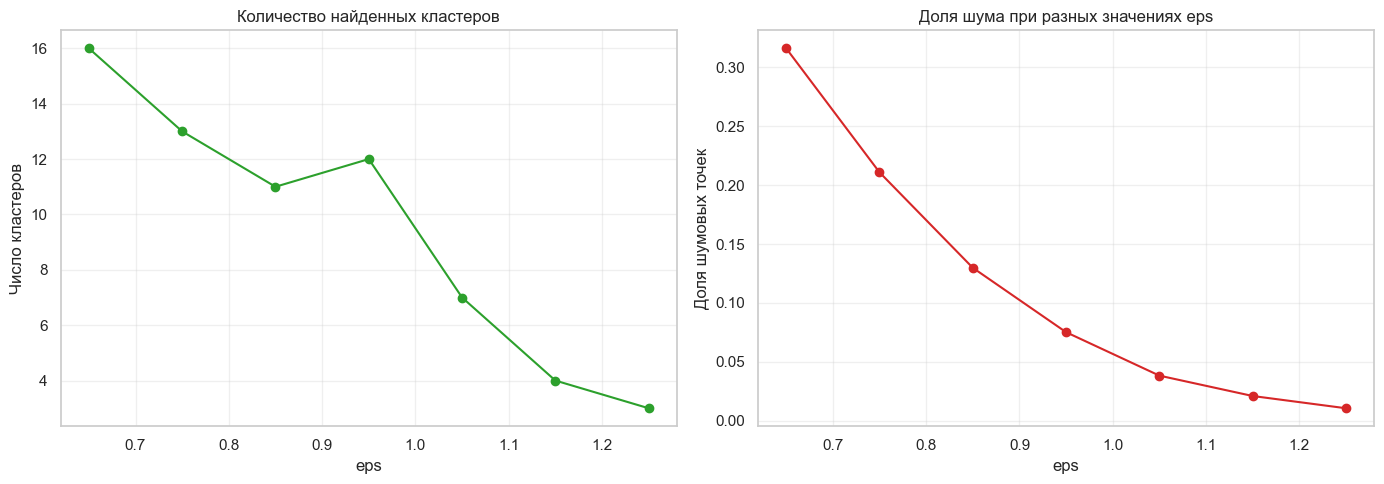

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(eps_results_df["eps"], eps_results_df["clusters"], marker="o", color="tab:green")
axes[0].set_title("Количество найденных кластеров")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Число кластеров")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eps_results_df["eps"], eps_results_df["noise_ratio"], marker="o", color="tab:red")
axes[1].set_title("Доля шума при разных значениях eps")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Доля шумовых точек")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
        


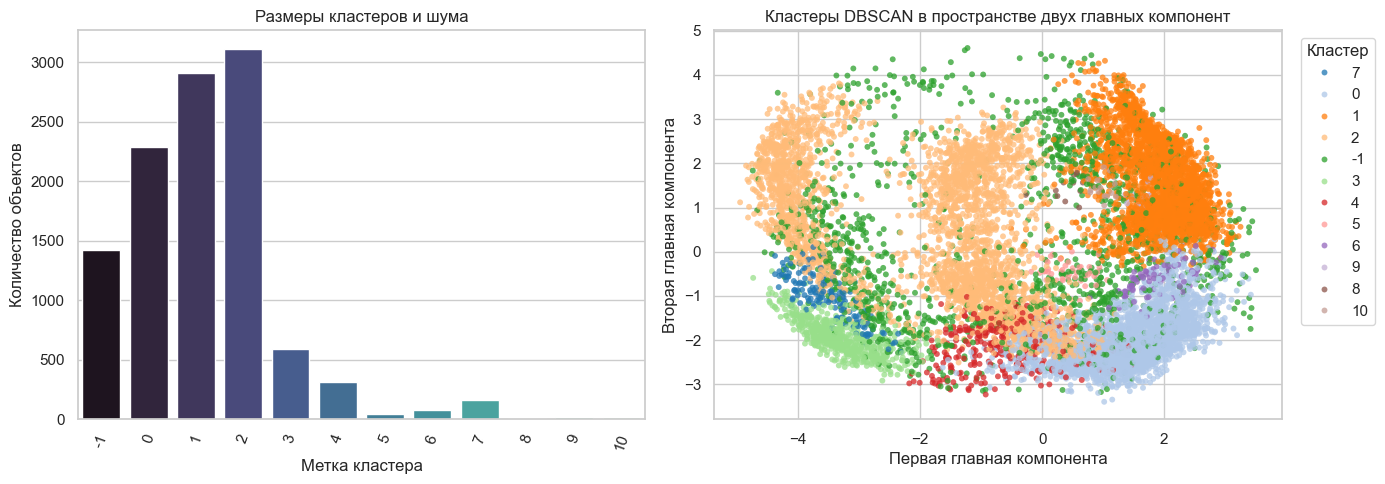

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_sizes_plot = cluster_sizes.copy().reset_index()
cluster_sizes_plot["cluster"] = cluster_sizes_plot["cluster"].astype(str)
sns.barplot(data=cluster_sizes_plot, x="cluster", y="count", ax=axes[0], palette="mako")
axes[0].set_title("Размеры кластеров и шума")
axes[0].set_xlabel("Метка кластера")
axes[0].set_ylabel("Количество объектов")
axes[0].tick_params(axis="x", rotation=70)

visual_df = pd.DataFrame(
    {
        "pc1": X_visual[:, 0],
        "pc2": X_visual[:, 1],
        "cluster": cluster_labels,
    }
)
visual_df["cluster_str"] = visual_df["cluster"].astype(str)

sns.scatterplot(
    data=visual_df,
    x="pc1",
    y="pc2",
    hue="cluster_str",
    palette="tab20",
    s=18,
    alpha=0.75,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("Кластеры DBSCAN в пространстве двух главных компонент")
axes[1].set_xlabel("Первая главная компонента")
axes[1].set_ylabel("Вторая главная компонента")
axes[1].legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()
        


**Вывод:** на датасете `Pendigits` алгоритм `DBSCAN` способен выделять плотные группы похожих траекторий пера и отдельно отмечать шумовые объекты. Подбор параметров `eps` и `min_samples` существенно влияет на число найденных кластеров и итоговое качество разбиения, поэтому в работе они выбираются не вручную, а на основе серии запусков и сравнения метрик.
        
